In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 1
def ex_1(k, x):
    for i in range(1, k + 1):
        if x < 0.5:
           x = x * 2
        else:
            x = x * 2 - 1
            
        # print(f"Step {i}: {x: .4f}")
        print(f"Step {i}: {x}")
    return x

In [3]:
# 3 a
df = pd.read_csv("regresie.csv", header=None)

z = df[0].to_numpy()

n = z.shape[0]

z = z.reshape((n,1))

A0 = np.ones((n,1))

A = np.hstack((z,A0))

print(A)


[[-1.40714697  1.        ]
 [ 0.55648558  1.        ]
 [-1.75848025  1.        ]
 [ 0.62609297  1.        ]
 [ 0.22020858  1.        ]
 [-1.61795313  1.        ]
 [-0.40157976  1.        ]
 [-1.54134177  1.        ]
 [-0.38021355  1.        ]
 [ 0.05043661  1.        ]
 [ 0.64241737  1.        ]
 [-1.07407777  1.        ]
 [-0.46868339  1.        ]
 [-0.41235493  1.        ]
 [-0.92205582  1.        ]
 [ 0.73983307  1.        ]
 [-0.04814211  1.        ]
 [-1.07150697  1.        ]
 [-0.96723792  1.        ]
 [ 0.63581789  1.        ]]


In [4]:
# 3 b

w = pd.read_csv("regresie.csv", header=None)
w = w[1].to_numpy()

x, _, _, _  = np.linalg.lstsq(A, w, rcond=None)

a = x[0]
b = x[1]

print(a)
print(b)

-1.8690381229420736
-1.1317755454924623


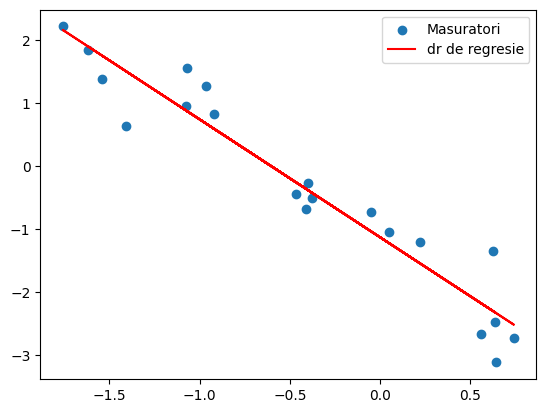

In [5]:
# 3 c

w_pred = A @ x

plt.scatter(z, w, label="Masuratori")
plt.plot(z, w_pred, color="red", label="dr de regresie")
plt.legend()
plt.show()

# Ex 2

In [6]:
# a - eliminarea gaussiana
def EG(A, b):
    A = A.copy()
    b = b.copy()
    n = A.shape[0]
    
    for k in range(0, n - 1):
        for i in range(k + 1, n):
            m = A[i][k] / A[k][k]
            
            for j in range(k, n):
                A[i][j] = A[i][j] - m * A[k][j]
            b[i] = b[i] - m * b[k]
    return A, b

In [7]:
# b - algoritmul UTRIS
def UTRIS(A, b):
    n = A.shape[0]
    x = b.copy()
    
    for i in range(n - 1, -1, -1):
        for j in range(i + 1, n):
            x[i] = x[i] - A[i][j] * x[j]
        x[i] = x[i] / A[i][i]
        
    return x

In [8]:
#  c - testare
n = 6
A = np.random.randn(n,n)

# genereaza o solutie pentru sistemul Ax = b
x_true = np.random.randn(n,1)
b = A @ x_true

A_tri, b_tri = EG(A, b)
x_computed = UTRIS(A_tri, b_tri)

print("Computed solution:")
print(x_computed)
print("\nTrue solution:")
print(x_true)

diff = np.max(np.abs(x_computed - x_true))
print("\nMax abs difference:", diff)

Computed solution:
[[-0.20228932]
 [-0.70078326]
 [ 0.26189259]
 [ 0.52380541]
 [ 1.46911733]
 [ 0.76165859]]

True solution:
[[-0.20228932]
 [-0.70078326]
 [ 0.26189259]
 [ 0.52380541]
 [ 1.46911733]
 [ 0.76165859]]

Max abs difference: 1.7763568394002505e-15


In [9]:
A2 = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b2 = np.array([ 8., -11., -3.])

new_A2,new_b2 = EG(A2, b2)

print("Upper triangular A2 is: ")
print(new_A2)

print("Modified b2 is: ")
print(new_b2)

Upper triangular A2 is: 
[[ 2.   1.  -1. ]
 [ 0.   0.5  0.5]
 [ 0.   0.  -1. ]]
Modified b2 is: 
[8. 1. 1.]


In [10]:
sol_x2 = UTRIS(new_A2, new_b2)
print(sol_x2)

[ 2.  3. -1.]
